# Approximating C and O Burning

Each of the reactions C+C, C+O, and O+O have multiple branches that all follow the same pattern.
These are:

$${}^{12}\mathrm{C} + {}^{12}\mathrm{C} \rightarrow \begin{cases}
       {}^{20}\mathrm{Ne} + \alpha \\
       {}^{23}\mathrm{Na} + p \\
       {}^{23}\mathrm{Mg} + n \end{cases}
$$

$${}^{12}\mathrm{C} + {}^{16}\mathrm{O} \rightarrow \begin{cases}
       {}^{24}\mathrm{Mg} + \alpha \\
       {}^{27}\mathrm{Al} + p \\
       {}^{27}\mathrm{Si} + n \end{cases}
$$

$${}^{16}\mathrm{O} + {}^{16}\mathrm{O} \rightarrow \begin{cases}
       {}^{28}\mathrm{Si} + \alpha \\
       {}^{31}\mathrm{P} + p \\
       {}^{31}\mathrm{S} + n \end{cases}
$$

in the first two of these sequences, the rate that produces a neutron is endothermic, and these rates are usually not considered.  For O-burning, the rate that produces a neutron has a branching probability of 5%, and is often
neglected as well.

In the "aprox"-family of networks, it is common to approximate these by removing the intermediate nucleus in the proton emission case.  

For example, or carbon-burning, we want to approximate ${}^{12}\mathrm{C} + {}^{12}\mathrm{C}$ by assuming
equilibriation of ${}^{23}\mathrm{Na}$.  This results in the following effective rates:

* ${}^{12}\mathrm{C}({}^{12}\mathrm{C},\alpha){}^{20}\mathrm{Ne}$ combining
  * the original ${}^{12}\mathrm{C}({}^{12}\mathrm{C},\alpha){}^{20}\mathrm{Ne}$
  * the sequence: ${}^{12}\mathrm{C}({}^{12}\mathrm{C},p){}^{23}\mathrm{Na}(p,\alpha){}^{20}\mathrm{Ne}$

* ${}^{12}\mathrm{C}({}^{12}\mathrm{C},\gamma){}^{24}\mathrm{Mg}$ combining the sequence
  ${}^{12}\mathrm{C}({}^{12}\mathrm{C},p){}^{23}\mathrm{Na}(p,\gamma){}^{24}\mathrm{Mg}$

* ${}^{20}\mathrm{Ne}(\alpha,\gamma){}^{24}\mathrm{Mg}$ combining
  * the original ${}^{20}\mathrm{Ne}(\alpha,\gamma){}^{24}\mathrm{Mg}$
  * the sequence: ${}^{20}\mathrm{Ne}(\alpha,p){}^{23}\mathrm{Na}(p,\alpha){}^{24}\mathrm{Mg}$

We also need to consider the reverse rates.  From the intermediate nucleus, ${}^{23}\mathrm{Na}$, we can
do ${}^{23}\mathrm{Na}(p,{}^{12}\mathrm{C}){}^{12}\mathrm{C}$.  This gives us 3 possible proton-captures
from the intermediate nucleus that we need to account for in order to approximate out that nucleus.  These 3 possible paths from the intermediate nucleus will serve as the normalization
for the approximate rates.

In [1]:
from pynucastro.rates.aprox_family_rates import make_CO_approximation

In [2]:
import pynucastro as pyna

In [3]:
rl = pyna.ReacLibLibrary()

## C+O burning network

In [4]:
net = pyna.network_helper(["p", "he4", "c12", "o16",
                           "ne20", "mg24", "si28",
                           "s32", "na23", "al27", "p31"])

In [5]:
r3a = net.get_rate_by_name("a(aa,g)C12")
r3a_reverse = net.get_rate_by_name("c12(g,aa)a")

net.remove_rates([r3a, r3a_reverse])

In [6]:
rcne = net.get_rate_by_name("ne20(c12,p)p31")
rcne2 = net.get_rate_by_name("ne20(c12,a)si28")
rcne_reverse = net.get_rate_by_name("p31(p,c12)ne20")
rcne2_reverse = net.get_rate_by_name("si28(a,c12)ne20")

net.remove_rates([rcne, rcne2, rcne_reverse, rcne2_reverse])

In [7]:
net.rates

[C12 + He4 ⟶ O16 + 𝛾,
 O16 + He4 ⟶ Ne20 + 𝛾,
 Ne20 + He4 ⟶ Mg24 + 𝛾,
 Na23 + p ⟶ Mg24 + 𝛾,
 Na23 + He4 ⟶ Al27 + 𝛾,
 Mg24 + He4 ⟶ Si28 + 𝛾,
 Al27 + p ⟶ Si28 + 𝛾,
 Al27 + He4 ⟶ P31 + 𝛾,
 Si28 + He4 ⟶ S32 + 𝛾,
 P31 + p ⟶ S32 + 𝛾,
 C12 + C12 ⟶ p + Na23,
 C12 + C12 ⟶ He4 + Ne20,
 O16 + C12 ⟶ p + Al27,
 O16 + C12 ⟶ He4 + Mg24,
 O16 + O16 ⟶ p + P31,
 O16 + O16 ⟶ He4 + Si28,
 Na23 + p ⟶ He4 + Ne20,
 Al27 + p ⟶ He4 + Mg24,
 P31 + p ⟶ He4 + Si28,
 O16 ⟶ He4 + C12,
 Ne20 ⟶ He4 + O16,
 Mg24 ⟶ p + Na23,
 Mg24 ⟶ He4 + Ne20,
 Al27 ⟶ He4 + Na23,
 Si28 ⟶ p + Al27,
 Si28 ⟶ He4 + Mg24,
 P31 ⟶ He4 + Al27,
 S32 ⟶ p + P31,
 S32 ⟶ He4 + Si28,
 Ne20 + He4 ⟶ p + Na23,
 Ne20 + He4 ⟶ C12 + C12,
 Na23 + p ⟶ C12 + C12,
 Mg24 + He4 ⟶ p + Al27,
 Mg24 + He4 ⟶ C12 + O16,
 Al27 + p ⟶ C12 + O16,
 Si28 + He4 ⟶ p + P31,
 Si28 + He4 ⟶ O16 + O16,
 P31 + p ⟶ O16 + O16]

In [8]:
rnaal = net.get_rate_by_name("na23(a,g)al27")
rnaal_reverse = net.get_rate_by_name("al27(g,a)na23")
ralp = net.get_rate_by_name("al27(a,g)p31")
ralp_reverse = net.get_rate_by_name("p31(g,a)al27")

net.remove_rates([rnaal, rnaal_reverse, ralp, ralp_reverse])

In [9]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 11
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  total number of rates: 34

  rates explicitly connecting nuclei: 34
  hidden rates: 0

  reaclib rates: 17
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 0
  derived rates: 17
  modified rates: 0
  custom rates: 0


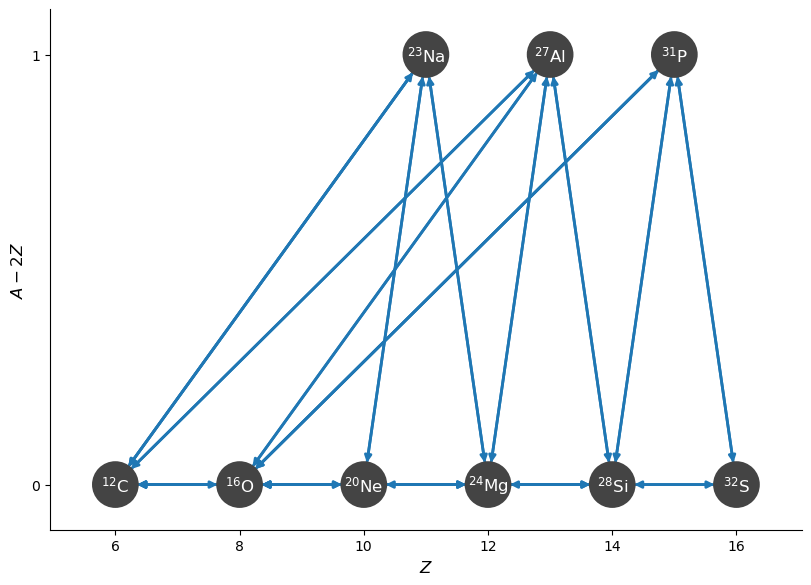

In [10]:
fig = net.plot(rotated=True)

In [11]:
net.write_network("full_net.py")

/raid/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


In [12]:
import full_net as fn

In [13]:
from scipy.integrate import solve_ivp
import numpy as np

In [14]:
rho = 1.e7
T = 3e9

X0 = np.zeros(fn.nnuc)
X0[fn.jc12] = 0.5
X0[fn.jo16] = 0.5

Y0 = X0 / fn.A

In [15]:
tmax = 100.0

sol = solve_ivp(fn.rhs, [0, tmax], Y0, method="BDF", jac=fn.jacobian,
                dense_output=True, args=(rho, T), rtol=1.e-6, atol=1.e-8)

In [16]:
import matplotlib.pyplot as plt

/raid/zingale/development/pynucastro/pynucastro/networks/python_network.py:694: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


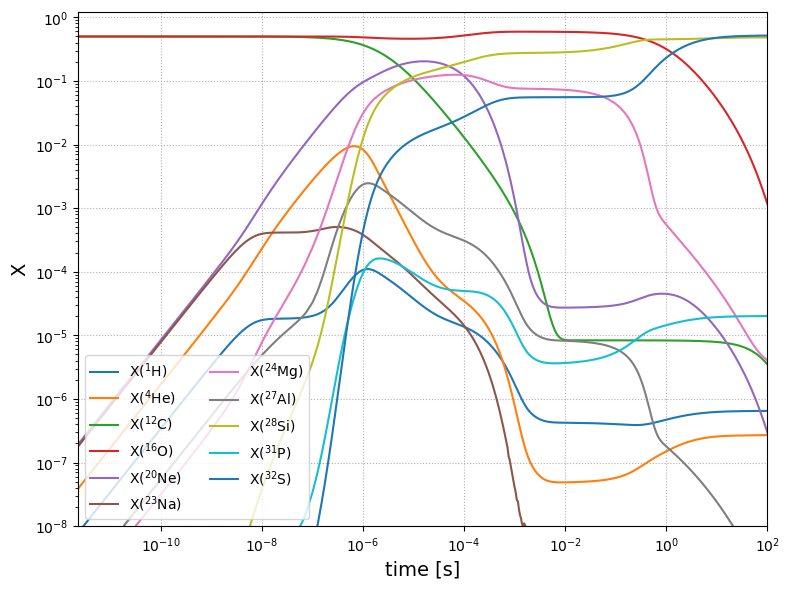

In [17]:
fig = net.plot_evolution(sol, ymin=1.e-8)

## An approximate network

In [18]:
crates = make_CO_approximation(rl.get_rates(), "C")

C12 C12 Ne20 Mg24 Na23


In [19]:
corates = make_CO_approximation(rl.get_rates(), "CO")

C12 O16 Mg24 Si28 Al27


In [20]:
orates = make_CO_approximation(rl.get_rates(), "O")

O16 O16 Si28 S32 P31


In [21]:
c12ag = rl.get_rate_by_name("c12(a,g)o16")
c12ag_reverse = rl.get_rate_by_name("o16(g,a)c12")
o16ag = rl.get_rate_by_name("o16(a,g)ne20")
o16ag_reverse = rl.get_rate_by_name("ne20(g,a)o16")

In [22]:
anet = pyna.PythonNetwork(rates=crates+corates+orates+[c12ag,c12ag_reverse,o16ag,o16ag_reverse])

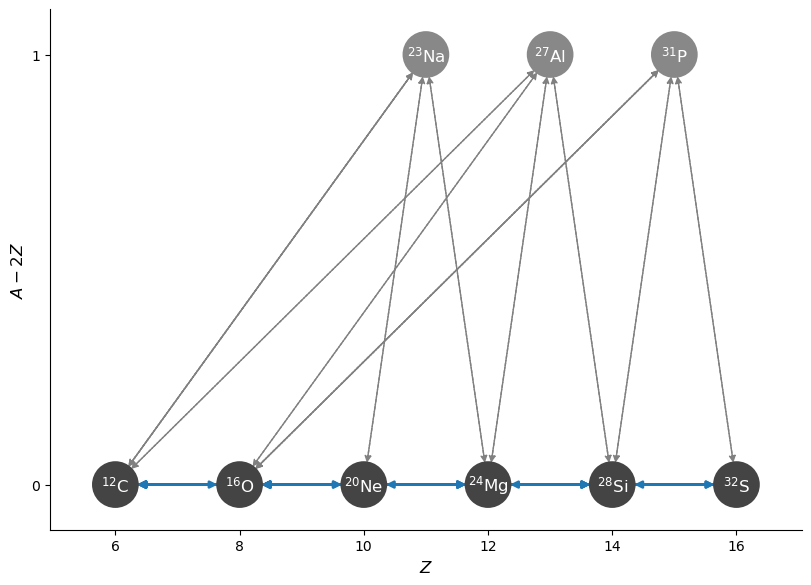

In [23]:
fig = anet.plot(rotated=True)

In [24]:
anet.summary()

Network summary
---------------
  explicitly carried nuclei: 7
  approximated-out nuclei: 3
  inert nuclei (included in carried): 0

  total number of rates: 52

  rates explicitly connecting nuclei: 22
  hidden rates: 30

  reaclib rates: 34
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 18
  derived rates: 0
  modified rates: 0
  custom rates: 0


In [25]:
anet.write_network("coapprox.py")

In [26]:
import coapprox as ap

In [27]:
rho = 1.e7
T = 3e9

X0 = np.zeros(ap.nnuc)
X0[ap.jc12] = 0.5
X0[ap.jo16] = 0.5

Y0 = X0 / ap.A

In [28]:
sol2 = solve_ivp(ap.rhs, [0, tmax], Y0, method="BDF", jac=ap.jacobian,
                dense_output=True, args=(rho, T), rtol=1.e-6, atol=1.e-8)

/raid/zingale/development/pynucastro/pynucastro/networks/python_network.py:694: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


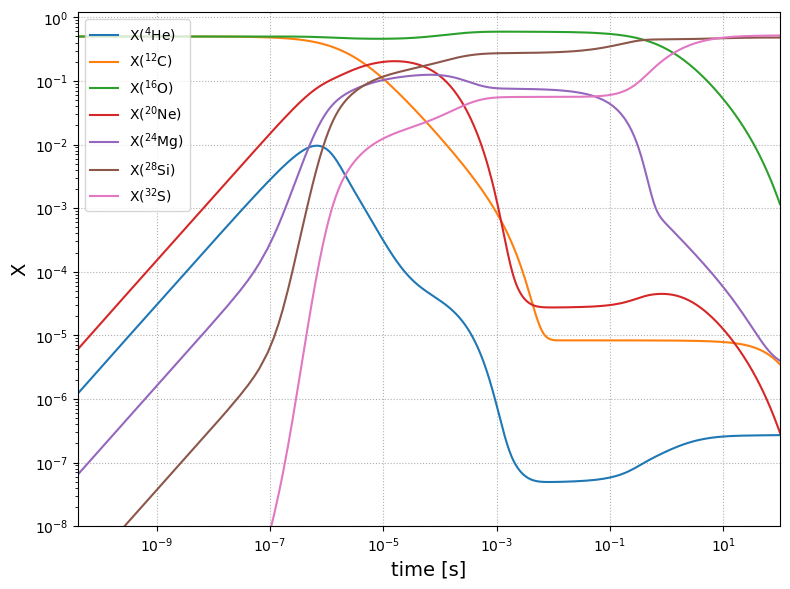

In [29]:
fig2 = anet.plot_evolution(sol2, ymin=1.e-8)

In [30]:
sol2

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.587e-10 ...  9.792e+01  1.000e+02]
        y: [[ 0.000e+00  1.189e-06 ...  6.745e-08  6.746e-08]
            [ 4.167e-02  4.166e-02 ...  2.965e-07  2.908e-07]
            ...
            [ 0.000e+00  2.075e-10 ...  1.716e-02  1.716e-02]
            [ 0.000e+00  1.775e-14 ...  1.619e-02  1.620e-02]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x7f1b56a4b890>
 t_events: None
 y_events: None
     nfev: 921
     njev: 15
      nlu: 81

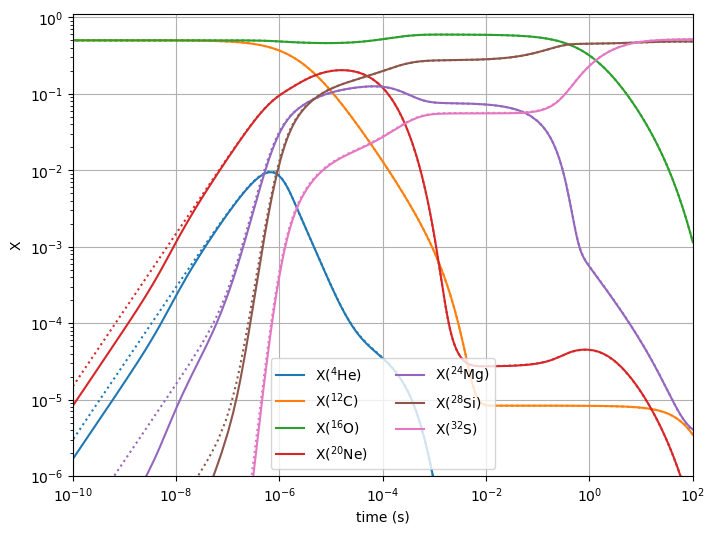

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111)

for i in range(ap.nnuc):
    ax.loglog(sol2.t, sol2.y[i,:] * ap.A[i],
              linestyle=":", color=f"C{i}")    
    idx = fn.names.index(ap.names[i])
    ax.loglog(sol.t, sol.y[idx,:] * fn.A[idx],
              label=rf"X$({pyna.Nucleus(fn.names[idx]).pretty})$",              
              linestyle="-", color=f"C{i}")

ax.set_ylim(1.e-6, 1.1)
ax.set_xlim(1.e-10, 100)
fig.set_size_inches((8,6))
ax.set_xlabel("time (s)")
ax.set_ylabel("X")
ax.legend(ncol=2, loc=8)
ax.grid()

In [32]:
fig.savefig("oburning.png")